In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import keras_tuner as kt

import zipfile
import os
import random

from skimage import io, transform
from skimage.metrics import structural_similarity as ssim

from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D, Dense, Flatten, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

In [3]:
zipRef = zipfile.ZipFile('A_23.zip', 'r')
zipRef.extractall()
zipRef.close()

In [4]:
imgDir = 'A_23'
allImg = os.listdir(imgDir)
numberOfImg = len(allImg)

Mengimport file gambar dan menyimpan list nama-nama file yang ada di dalam folder. 

### a. EDA

#### Store Images in a List

In [5]:
def preprocessImg(targetSize=(100, 100)):
    img = list()

    for file in allImg:
        curImg = io.imread(os.path.join(imgDir, file), as_gray=False)
        curImg = transform.resize(curImg, targetSize)
        img.append(curImg)

    return np.array(img)

prepImg = preprocessImg()

Load file gambar dan simpan dalam list. Gambar juga akan langsung di resize menjadi 100x100 sesuai ketentuan soal. 

#### Check number of images and Image size

In [6]:
print('Number of Image:', prepImg.shape[0])
print('Image size: ', prepImg.shape[1:])

Number of Image: 1074
Image size:  (100, 100, 3)


Jumlah gambar yang ada dalam data sebanyak 1074 foto dan sizenya telah berhasil diubah menjadi 100x100, serta memiliki 3 color channel. 

#### Sample of Images

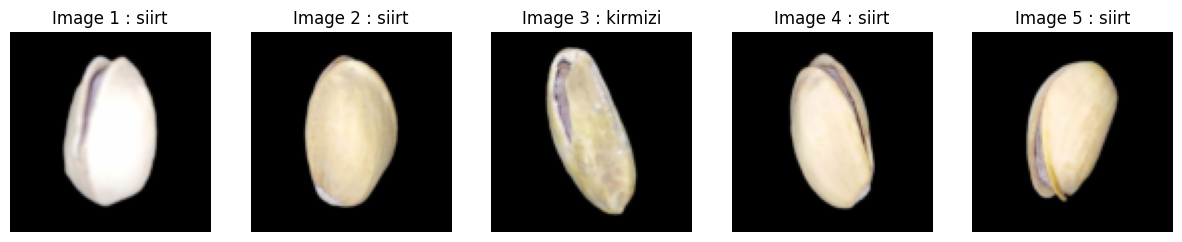

In [7]:
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(prepImg[(i*12)])
    plt.title(f'Image {i+1} : {allImg[i*12].split()[0]}')
    plt.axis('off')
plt.show()

#### Pixel Value Distribution for an Image

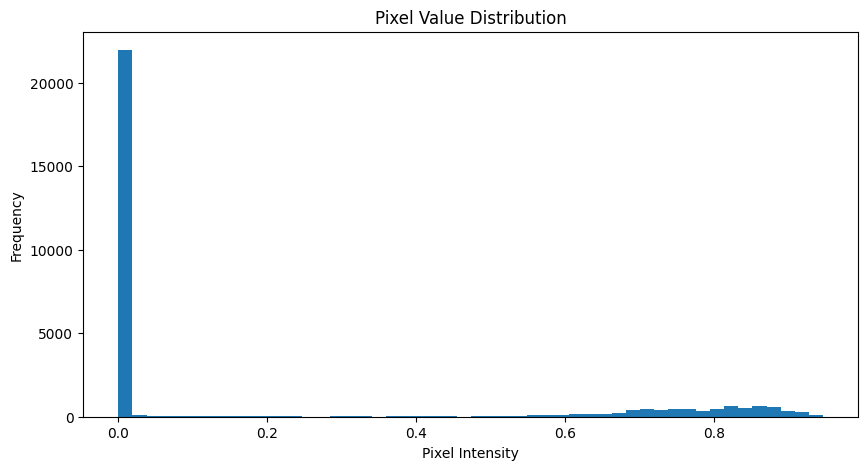

In [8]:
plt.figure(figsize=(10,5))
plt.hist(prepImg[134].flatten(), bins=50)
plt.title('Pixel Value Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

Hasil histogram menunjukkan bahwa gambar didominasi dengan warna hitam dan hal tersebut benar karena background dari gambar yang diterima berwarna hitam. Dikuti dengan warna lain yang cukup kecil, sehingga dapat dilhat pada histogramnya, range 0.4-0.9 terdapat value tetapi tidak setinggi 0.0

## B. Split Data

Saat gambar di load, gambar juga telah di resize menjadi 100x100, sehingga tidak akan diresize kembali

#### Create Noise Images

In [9]:
def addNoise(img, mean=0.0, std=0.1):
    noise = np.random.normal(mean, std, size=img.shape)
    noisyImg = img+noise

    return np.clip(noisyImg, 0., 1.)

noisyImg = addNoise(prepImg)

print(prepImg.shape, noisyImg.shape)

(1074, 100, 100, 3) (1074, 100, 100, 3)


Membuat function untuk menambahkan noise kepada image dan akan disimpan dalam sebuah variabel bernama noisyImg. Value noise diperoleh dengan menggunakan gaussian/normal dengan mean 0 dan standar deviasi 0.1. Setelah ditambahkan value noisenya, dilakukan pengecekan untuk shape dari gambar yang ditambahkan noise dan gambar asli. untuk memastkan shapenya tidak berubah

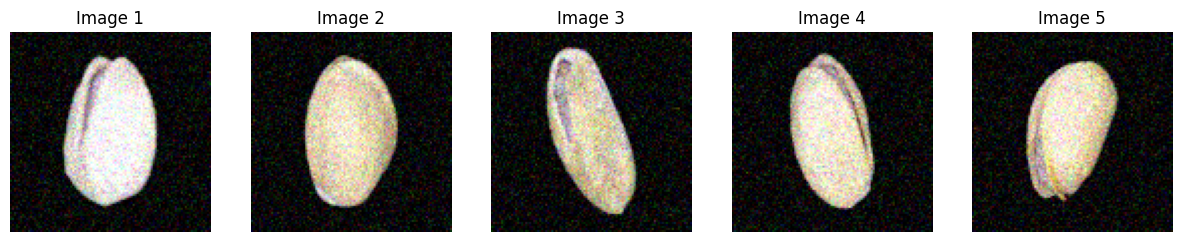

In [10]:
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(noisyImg[(i*12)])
    plt.title(f'Image {i+1}')
    plt.axis('off')
plt.show()

Dari plot diatas, gambar telah berhasil ditambahkan noise, dan terlihat dari gambar yang menjadi lebih pixelated. 

#### Splitting Data into Train, Test, and Val data

In [11]:
xTrainNoisy, xTempNoisy = train_test_split(noisyImg, test_size=0.2, random_state=42)
xValNoisy, xTestNoisy = train_test_split(xTempNoisy, test_size=0.5, random_state=42)

xTrain, xTemp = train_test_split(prepImg, test_size=0.2, random_state=42)
xVal, xTest = train_test_split(xTemp, test_size=0.5, random_state=42)

print(xTrainNoisy.shape, xValNoisy.shape, xTestNoisy.shape)
print(xTrain.shape, xVal.shape, xTest.shape)

(859, 100, 100, 3) (107, 100, 100, 3) (108, 100, 100, 3)
(859, 100, 100, 3) (107, 100, 100, 3) (108, 100, 100, 3)


## C. Creating Model

Pembuatan model menggunakan model functional dengan input shape sesuai gambar yang dimiliki dan ketentuan soal, yaitu (100, 100, 3). Pada model baseline, terdapat 10 layer. Untuk setiap layer, terdapat jumlah-jumlah channel/filter yang berbeda. Terdapat 2 bagian yaitu encoder dan decoder. Encoder akan melakukan downsampling (mengurangi dimensi gambar), lalu akan dilanjutkan dengan Decoder yang akan melakukan Upsampling (menambahkan dimensi gambar). Karena tidak ada strides yang ditentukan dan padding same, maka besar dimensi tidak berubah. Akan tetapi, penggunaan MaxPooling akan menyebabkan besar dimensi mengecil 2x lipat. Sebaliknya, Upsampling akan menyebabkan besar dimensi membesar 2x lipat.

In [12]:
inputImg = Input(shape=(100, 100, 3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputImg)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoder = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoder)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoder = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(inputImg, decoder)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 100, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

Model yang telah dibuat akan di fit dengan data train, dengan jumlah epoch sebanyak 20.

In [13]:
autoencoderHistory = autoencoder.fit(xTrainNoisy, xTrain,
                                     epochs=20,
                                     batch_size=32,
                                     validation_data = (xValNoisy, xVal),
                                     verbose=2)

Epoch 1/20
27/27 - 9s - 349ms/step - loss: 0.0660 - val_loss: 0.0118
Epoch 2/20
27/27 - 4s - 142ms/step - loss: 0.0117 - val_loss: 0.0072
Epoch 3/20
27/27 - 1s - 40ms/step - loss: 0.0072 - val_loss: 0.0040
Epoch 4/20
27/27 - 1s - 23ms/step - loss: 0.0033 - val_loss: 0.0028
Epoch 5/20
27/27 - 1s - 22ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 6/20
27/27 - 1s - 22ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 7/20
27/27 - 1s - 23ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 8/20
27/27 - 1s - 23ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 9/20
27/27 - 1s - 21ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 10/20
27/27 - 1s - 23ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 11/20
27/27 - 1s - 23ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 12/20
27/27 - 1s - 23ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 13/20
27/27 - 1s - 21ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 14/20
27/27 - 1s - 23ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 15/20
27/27 - 1s - 23ms/step - loss

In [14]:
autoencoderLoss = autoencoder.evaluate(xTestNoisy, xTest)
print(f'Autoencoder MSE: {autoencoderLoss:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step - loss: 9.4361e-04
Autoencoder MSE: 0.0009


Dari hasil evaluasi dengan menggunakan data test, model yang dibuat memiliki MSE yang sangat kecil, yaitu 0.0009. Selanjutkan model akan membuat prediksi untuk gambar yang dibersihkan dari noise.

In [15]:
encPred = autoencoder.predict(xTestNoisy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step


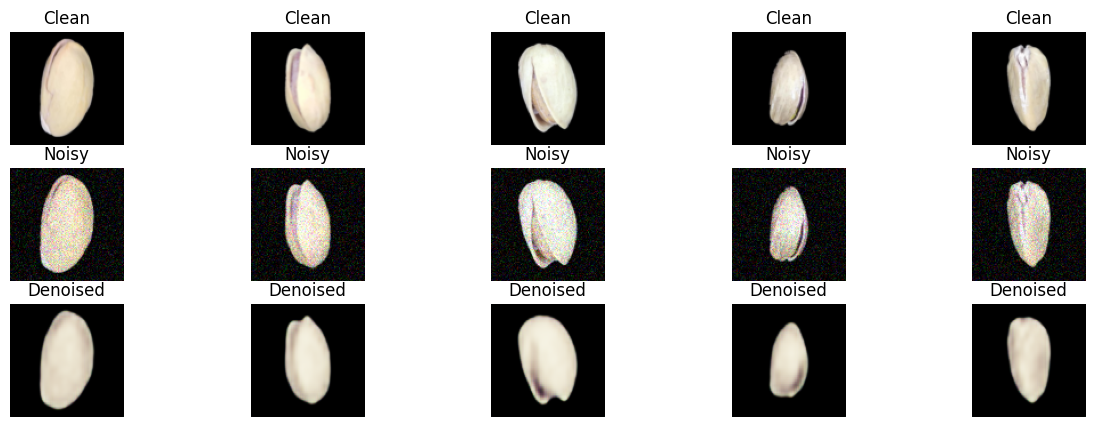

In [16]:
plt.figure(figsize=(15,5))
for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(xTest[i])
    plt.title('Clean')
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(xTestNoisy[i])
    plt.title('Noisy')
    plt.axis('off')

    plt.subplot(3,5,i+11)
    plt.imshow(encPred[i])
    plt.title('Denoised')
    plt.axis('off')
plt.show()

Hasil dari model sudah cukup baik, karena telah berhasil hampir mereplikasi dataset asli dan menghilangkan noise yang ada pada gambar. Hanya sedikit kurang detail dan tajam untuk gambar-gambarnya. 

In [24]:
encPredSsim = []

for i in range(encPred.shape[0]):
    pred = encPred[i].squeeze()
    clean = xTest[i].squeeze()

    score, diff = ssim(pred, clean, full=True, data_range=1.0, channel_axis=2)

    encPredSsim.append(score)

In [25]:
avgSsim = np.mean(encPredSsim)
print("SSIM Score:", avgSsim)

SSIM Score: 0.9541318


Hasil skor ssim yang diterima yaitu 0.95. Skor ini sangat dekat dengan angka 1, sehingga dapat ditarik kesimpulan bahwa gambar yang dihasilkan oleh model autoencoder hampir sangat identik dengan gambar aslinya. Maka, model ini telah berhasil menghilangkan noise dengan sangat baik.

## d. Modified Model 

Pembuatan model yang di modified akan menggunakan model functional dengan input yang sama seperti model baseline. Pada model ini, terdapat 15 layer, dan jumlah filter yang digunakan beragam dari 64 hingga 256. Pada model modified terdapat penggunaan cropping2d, untuk menghilangkan dimensi lebih akibat perbedaan perhitungan. Pada dimensi, akibat MaxPooling2D akan bergerak dari 100x100 -> 50x50 -> 25x25 -> 13x13. Saat dilakukan upscaling, 13x13 akan menjadi 26x26, bukan 25x25 dan dapat mengakibatkan mis-match pada dimensi hasil. Sehingga akan dilakukan cropping. 

In [ ]:
inputModImg = Input(shape=(100, 100, 3))
xMod = Conv2D(64, (3, 3), activation='relu', padding='same')(inputModImg)
xMod = MaxPooling2D((2, 2), padding='same')(xMod)
xMod = Conv2D(128, (3, 3), activation='relu', padding='same')(xMod)
xMod = MaxPooling2D((2, 2), padding='same')(xMod)
xMod = Conv2D(256, (3, 3), activation='relu', padding='same')(xMod)
encoderMod = MaxPooling2D((2, 2), padding='same')(xMod)

xMod = Conv2D(256, (3, 3), activation='relu', padding='same')(encoderMod)
xMod = Conv2DTranspose(256, (3, 3), strides=(2, 2), activation='relu', padding='same')(xMod)
xMod = Cropping2D(cropping=((0, 1), (0, 1)))(xMod)
xMod = Conv2D(128, (3, 3), activation='relu', padding='same')(xMod)
xMod = Conv2DTranspose(128, (3, 3), strides=(2, 2), activation='relu', padding='same')(xMod)
xMod = Conv2D(64, (3, 3), activation='relu', padding='same')(xMod)
xMod = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(xMod)
decoderMod = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(xMod)

autoencoderMod = Model(inputModImg, decoderMod)
autoencoderMod.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoderMod.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 26, 26, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 50, 50, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 50, 50, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 100, 100, 64)   │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 100, 100, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,106,051 (8.03 MB)

 Trainable params: 2,106,051 (8.03 MB)

 Non-trainable params: 0 (0.00 B)

Model modified akan di train dengan jumlah epoch 100, lalu akan menggunakan EarlyStopping juga. Apabila value val_loss tidak turun lebih dari 10x berturut-turut, maka model akan memberhentikan proses fittingnya. 

In [27]:
autoencoderModHistory = autoencoderMod.fit(xTrainNoisy, xTrain,
                                     epochs=100,
                                     batch_size=32,
                                     validation_data = (xValNoisy, xVal),
                                     verbose=2, callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, monitor='val_loss')
    ])

Epoch 1/100
27/27 - 27s - 1s/step - loss: 0.0875 - val_loss: 0.0218
Epoch 2/100
27/27 - 21s - 767ms/step - loss: 0.0093 - val_loss: 0.0046
Epoch 3/100
27/27 - 2s - 81ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 4/100
27/27 - 3s - 94ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 5/100
27/27 - 3s - 94ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 6/100
27/27 - 3s - 93ms/step - loss: 0.0027 - val_loss: 0.0024
Epoch 7/100
27/27 - 2s - 81ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 8/100
27/27 - 3s - 96ms/step - loss: 0.0026 - val_loss: 0.0029
Epoch 9/100
27/27 - 2s - 81ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 10/100
27/27 - 2s - 81ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 11/100
27/27 - 3s - 95ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 12/100
27/27 - 3s - 93ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 13/100
27/27 - 3s - 94ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 14/100
27/27 - 3s - 93ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 15/100
27/27 - 2s - 82

In [28]:
autoencoderModLoss = autoencoderMod.evaluate(xTestNoisy, xTest)
print(f'Autoencoder MSE: {autoencoderModLoss:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 529ms/step - loss: 4.4417e-04
Autoencoder MSE: 0.0004


Hasil evaluasi model yang di modify menggunakan dataset Test lebih baik dibandingkan model baseline. MSE yang dihasilkan untuk model modified ini hanya 0.0004, artinya model ini sangat mirip dengan data asli (karena hanya berbeda 0.0004). Selanjutnya, model akan membuat prediksi untuk gambar yang dibersihkan dari noise (denoising)

In [29]:
encModPred = autoencoderMod.predict(xTestNoisy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step


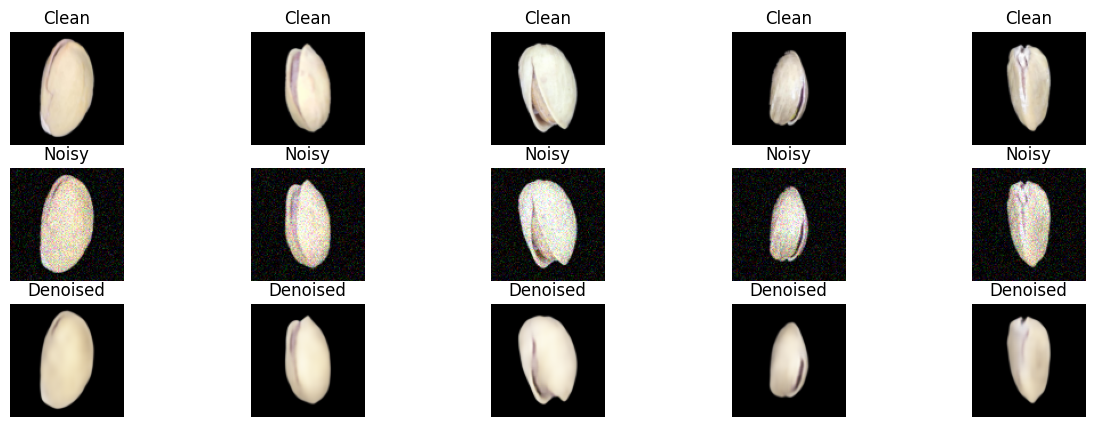

In [30]:
plt.figure(figsize=(15,5))
for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(xTest[i])
    plt.title('Clean')
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(xTestNoisy[i])
    plt.title('Noisy')
    plt.axis('off')

    plt.subplot(3,5,i+11)
    plt.imshow(encModPred[i])
    plt.title('Denoised')
    plt.axis('off')
plt.show()

Hasil dari model sudah sangat baik dan berhasil hampir sepenuhnya mereplikasi gambar asli dan menghilangkan noise dari gambar. Hasil prediksi model ini juga sudah lebih detail dibandingkan model baseline. 

In [38]:
encModPredSsim = []

for i in range(encPred.shape[0]):
    pred = encModPred[i].squeeze()
    clean = xTest[i].squeeze()

    score, diff = ssim(pred, clean, full=True, data_range=1.0, channel_axis=2)

    encModPredSsim.append(score)

In [39]:
avgModSsim = np.mean(encModPredSsim)
print("SSIM Score:", avgModSsim)

SSIM Score: 0.96297646


Hasil SSIM Score dari model modified ini lebih baik dibandingkan baseline. Model ini telah memiliki tingkat kemiripan 96% dengan gambar asli. 

## E. Evaluasi

Dari plot hasil prediksi model, dapat dilihat bahwa gambar yang dihasilkan model yang di modify lebih detail dan tajam dibandingkan model baseline. Hal tersebut dapat dilihat pada hasil denoising ke 3 dan ke 4, dimana pada bagian kacang yang terbuka jauh lebih detail. \
\
Dari hasil MSE pun dapat dilihat bahwa model baseline memiliki MSE yang sedikit lebih tinggi dibandingkan model modified: 0.0009 vs 0.0004. Kedua value tersebut sudah sangat kecil, akan tetapi model modified memiliki hasil yang sedikit lebih baik\
\
Untuk hasil dari SSIM scorenya, keduanya sudah memiliki nilai SSIM yang sangat tinggi, yaitu 95% untuk baseline dan 96% untuk modified. \
\
Maka dapat disimpulkan, bahwa model yang dibuat telah berhasil melakukan denoising dengan sangat bagus. Baik itu untuk model baseline, maupun model yang di modify tersebut.

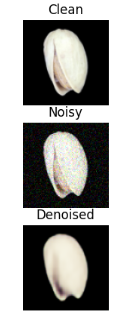 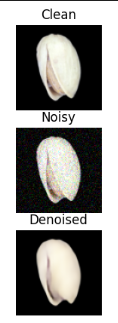 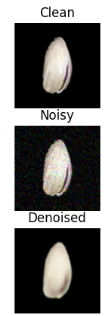 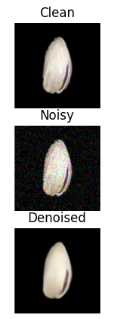